# Heart Failure Detection Project

Authors: Nikhil Vijayvergiya, Wilson Ide, Matthew Erickson, Ethan Fong, Harisri


Introduction:


Imports

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import kagglehub
from kagglehub import KaggleDatasetAdapter

Now we will retrieve and download the data from our dataset off of Kaggle.



In [102]:
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Path to dataset files:", path)
heart_data = path + "/heart.csv"
df = pd.read_csv(heart_data)
df.head()


Path to dataset files: /Users/nikvijay/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Now we want to observe the cleanness of our data. We first check for null or invalid values:

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [104]:
df.shape

(918, 12)

We now check for duplicates:

In [105]:
### Check for duplicates


print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


## Preprocessing
We now need to preprocess the data so it's suitable for learning. We will need to both convert data in the form of letters into numbers, as well as standardize the data. We will also need to separate the data into features and labels. 

Here we are using one-hot encoding to represent both Chest pain types, RestingECG, and ST_Slope.


In [106]:
df = pd.get_dummies(df, drop_first=True)
boolean_columns = df.select_dtypes(include='bool').columns
df[boolean_columns] = df[boolean_columns].astype(int)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


Now we need to check the data for outliers to see if our data is behaving normally. We will visualize the distributions for each feature.

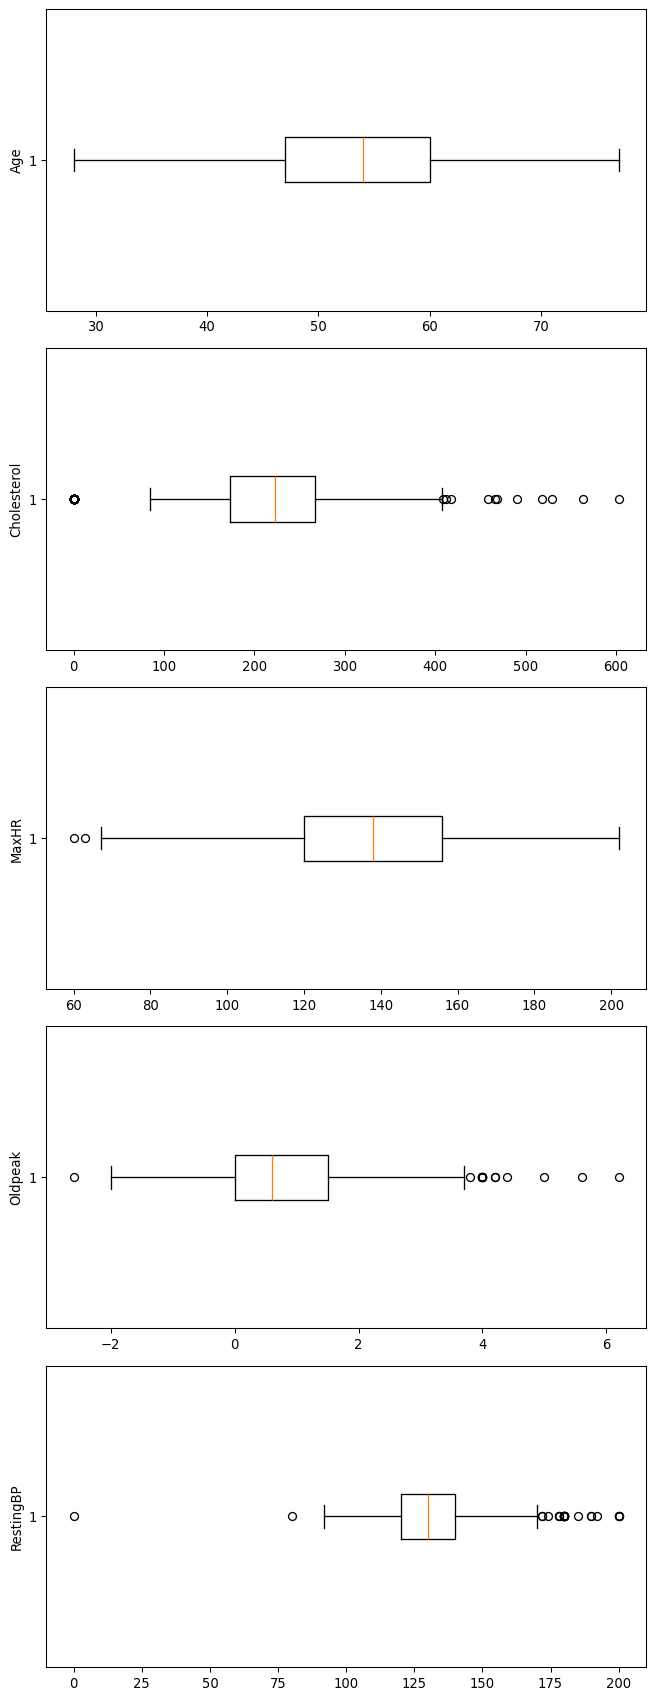

In [107]:
df.describe()

boolean_columns = df.columns[df.nunique() == 2]
numeric_cols = df.columns.difference(boolean_columns)
fig, axs = plt.subplots(len(numeric_cols), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(numeric_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

After visualizing this data, we can see relatively normal data. We will leave the outliers on the higher sides of RestingBP, Oldpeak, and cholesterol as those high outliers are actually realistic values for some people suffering from poor health. However, oddly it looks like there are many values of cholesterol that are 0 which should not be possible. We will also need to deal with the datapoints that have restingBP as 0.

In [108]:
# Sum and print number of 0s found in Cholesterol
cholesterol_zeros = (df['Cholesterol'] == 0).sum()
print(f"Number of zeros in 'Cholesterol': {cholesterol_zeros}")

BP_zeros = (df['RestingBP'] == 0).sum()
print(f"Number of zeros in 'BP': {BP_zeros}")


Number of zeros in 'Cholesterol': 172
Number of zeros in 'BP': 1


We have 172/982 datapoints with Cholesterol equal to 0 which is not good. For these datapoints we will use K nearest neighbors to fill in new cholesterol values as well as the one invalid RestingBP value. 

To avoid the curse of dimensionality we will use selected relevant features: Cholesterol, RestingBP, Age, and MaxHR.

Missing: 0


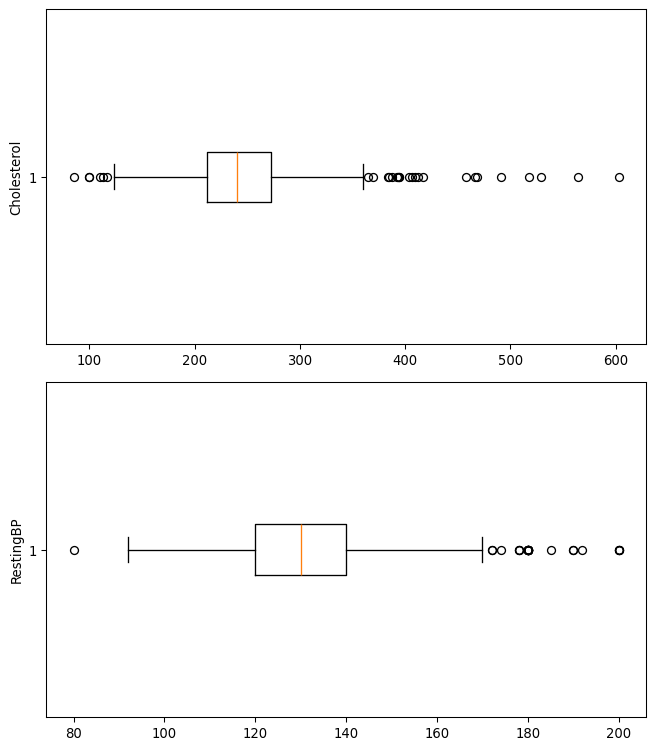

In [109]:
from sklearn.impute import KNNImputer

df2 = df[['Cholesterol', 'RestingBP', 'Age', 'MaxHR']].copy()
df2['Cholesterol'] = df2['Cholesterol'].replace(0, np.nan)
df2['RestingBP'] = df2['RestingBP'].replace(0, np.nan)


imputer = KNNImputer()
imputer.fit(df2)
df2_trans = imputer.transform(df2)
df2_real = pd.DataFrame(df2_trans, columns=['Cholesterol', 'RestingBP', 'Age', 'MaxHR'])
columns = df2_real.columns

print('Missing: %d' % sum(np.isnan(df2_trans).flatten()))
df['Cholesterol'] = df2_real['Cholesterol']
df['RestingBP'] = df2_real['RestingBP']

fig, axs = plt.subplots(2, 1, figsize=(7, 8), dpi=95)
axs[0].boxplot(df['Cholesterol'], vert=False)
axs[0].set_ylabel('Cholesterol')
axs[1].boxplot(df['RestingBP'], vert=False)
axs[1].set_ylabel('RestingBP')


plt.tight_layout()
plt.show()


Great! Our cholesterol and blood pressure values are now all realistic and possible values!

Our next steps are to standardize the data and split it into labels, features, and then split both of those into training and testing data. We will use sklearns StandardScaler for normalizing the data as well as sklearns train_test_split to split between testing and training data. We will use 80% training data and 20% testing data.

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into features and labels
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Here we are standardizing all of the features before we split the data
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Now we split the data into our training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


We will convert non-numerical data into numerical data then normalize all features. The graphs should show that the data for each feature has been standardized.

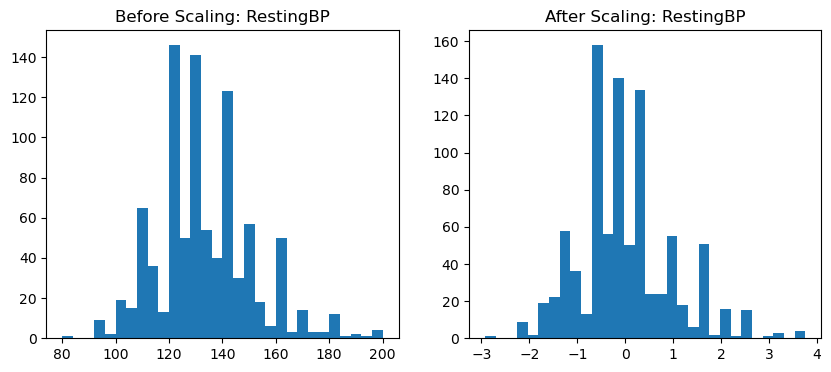

In [111]:
X_df = pd.DataFrame(X, columns=X.columns)

feature = X.columns[1]  # column name

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(X[feature], bins=30)
plt.title(f"Before Scaling: {feature}")

plt.subplot(1,2,2)
plt.hist(X_scaled[feature], bins=30)
plt.title(f"After Scaling: {feature}")

plt.show()

## Logistic Regression

Feature reduction: We will use Logisitic Regression with l1 (Lasso) regularization to get rid of features with low variance while training this model.

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV


temp_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=temp_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=50,            
    n_jobs=-1          
)
grid.fit(X_train, y_train)
best_c = grid.best_params_['C']

print("Best C:", best_c)
print("Best CV Score:", grid.best_score_)

model = LogisticRegression(penalty='l1', solver='liblinear', C=best_c)

model.fit(X_train, y_train)

selected_features = X_train.columns[model.coef_[0] != 0]

print("Selected Features: ", selected_features)
print("")
print("Non selected Features: ", X_train.columns[model.coef_[0] == 0])

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("")

# print(classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)  # 2x2: [[tn, fp],[fn, tp]]
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)



Best C: 0.3
Best CV Score: 0.860952380952381
Selected Features:  Index(['Age', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

Non selected Features:  Index(['RestingBP', 'Cholesterol', 'RestingECG_Normal', 'RestingECG_ST'], dtype='object')

Accuracy: 0.853
Precision: 0.908
Recall: 0.832
F1 Score: 0.868
TN: 68 FP: 9 FN: 18 TP: 89


Best C: 0.01
Best CV Score: 0.8606666666666666

Accuracy: 0.859
Precision: 0.909
Recall: 0.841
F1 Score: 0.874
TN: 68 FP: 9 FN: 17 TP: 90


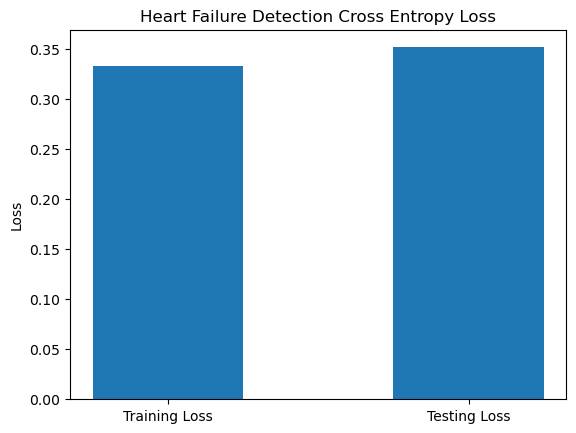

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss



temp_model_2 = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)

grid_2 = GridSearchCV(
    estimator=temp_model_2,
    param_grid=param_grid,
    scoring='accuracy',
    cv=50,            
    n_jobs=-1          
)
grid_2.fit(X_train, y_train)
best_c = grid_2.best_params_['C']

print("Best C:", best_c)
print("Best CV Score:", grid_2.best_score_)

model2 = LogisticRegression(penalty='l2', solver='liblinear', C=best_c)
model2.fit(X_train, y_train)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model2.predict(X_test)

print("")

acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)  # 2x2: [[tn, fp],[fn, tp]]
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)





train_loss = log_loss(y_train, model.predict_proba(X_train))
test_loss = log_loss(y_test, model.predict_proba(X_test))

labels = ['Training Loss', 'Testing Loss']
values = [train_loss, test_loss]

plt.bar(labels, values, width=0.5)
plt.ylabel('Loss')
plt.title('Heart Failure Detection Cross Entropy Loss')
plt.show()

It looks like our model didn't overfit thankfully. Our metrics also came out pretty well, although for a medical detection model we'd hope recall would be a little bit higher.

We will not analyze our feature importance for both models.

L1 coefficients: [[ 0.12615559  0.          0.          0.45386096 -0.18185446  0.40374941
   0.533631   -0.57658672 -0.52162982 -0.2064065   0.          0.
   0.48650096  0.52039626 -0.59911868]]
L2 coefficients: [[ 0.12932031  0.03464184  0.03480764  0.23399131 -0.21195087  0.26797605
   0.28128175 -0.29580705 -0.22972977 -0.08316792 -0.01151866  0.00807501
   0.34064762  0.35404469 -0.40241468]]


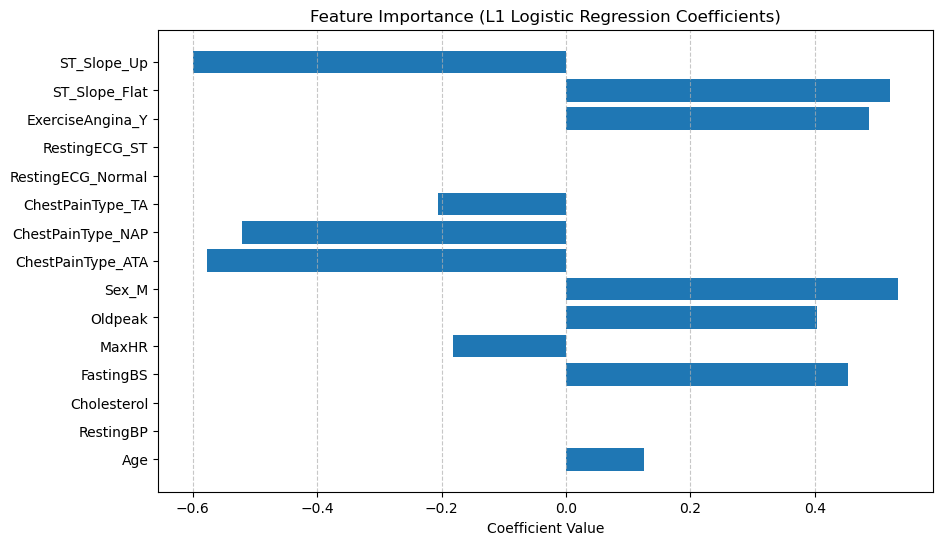

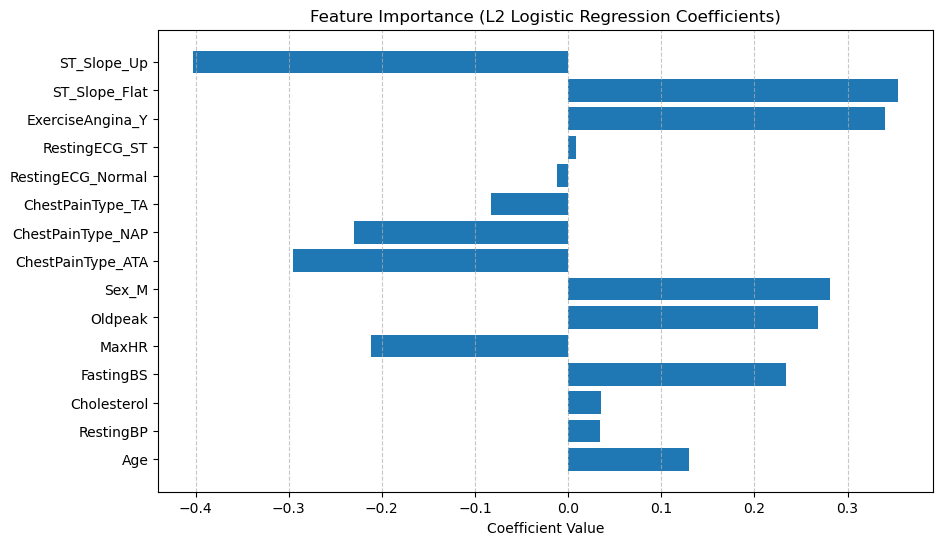

In [114]:
print("L1 coefficients:", model.coef_)
print("L2 coefficients:", model2.coef_)

coef = pd.Series(model.coef_[0], index=X.columns)

plt.figure(figsize=(10,6))
plt.barh(coef.index, coef.values)

plt.xlabel('Coefficient Value')
plt.title('Feature Importance (L1 Logistic Regression Coefficients)')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

coef2 = pd.Series(model2.coef_[0], index=X.columns)

plt.figure(figsize=(10,6))
plt.barh(coef2.index, coef2.values)

plt.xlabel('Coefficient Value')
plt.title('Feature Importance (L2 Logistic Regression Coefficients)')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()